In [30]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [31]:
#Data Extraction, Cleaning, and Balancing
big_file_name = "complaints.csv"
columns_to_keep = ['Product', 'Consumer complaint narrative']

print("Processing raw dataset in chunks...")

clean_chunks = []
category_mapping = {
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit Reporting',
    'Credit reporting or other personal consumer reports': 'Credit Reporting',
    'Credit reporting': 'Credit Reporting',
    'Credit card or prepaid card': 'Credit Card',
    'Credit card': 'Credit Card',
    'Prepaid card': 'Credit Card',
    'Payday loan, title loan, personal loan, or advance loan': 'Personal/Payday Loan',
    'Payday loan, title loan, or personal loan': 'Personal/Payday Loan',
    'Payday loan': 'Personal/Payday Loan',
    'Consumer Loan': 'Personal/Payday Loan',
    'Checking or savings account': 'Bank Account',
    'Bank account or service': 'Bank Account',
    'Money transfer, virtual currency, or money service': 'Money Transfer',
    'Money transfers': 'Money Transfer',
    'Debt collection': 'Debt Collection',
    'Mortgage': 'Mortgage',
    'Student loan': 'Student Loan',
    'Vehicle loan or lease': 'Vehicle Loan'
}


Processing raw dataset in chunks...


In [32]:
# 1. Read in chunks and clean
for chunk in pd.read_csv(big_file_name, chunksize=100000, usecols=columns_to_keep, low_memory=False):
    chunk_clean = chunk.dropna(subset=['Consumer complaint narrative']).copy()
    chunk_clean['Product_Clean'] = chunk_clean['Product'].map(category_mapping)
    chunk_clean = chunk_clean.dropna(subset=['Product_Clean'])
    
    if not chunk_clean.empty:
        clean_chunks.append(chunk_clean[['Product_Clean', 'Consumer complaint narrative']])

full_clean_df = pd.concat(clean_chunks, ignore_index=True)

In [33]:
# 2. Balance classes to exactly 5000 each (Bulletproof method)
print("Balancing classes to 5000 samples per category...")
balanced_chunks = []
for category in full_clean_df['Product_Clean'].unique():
    category_data = full_clean_df[full_clean_df['Product_Clean'] == category]
    sampled_data = category_data.sample(min(len(category_data), 5000), random_state=42)
    balanced_chunks.append(sampled_data)

df = pd.concat(balanced_chunks, ignore_index=True)
print(f"Final balanced dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Balancing classes to 5000 samples per category...
Final balanced dataset shape: 45000 rows, 2 columns



Category Counts:
Product_Clean
Credit Reporting        5000
Student Loan            5000
Credit Card             5000
Debt Collection         5000
Money Transfer          5000
Personal/Payday Loan    5000
Mortgage                5000
Bank Account            5000
Vehicle Loan            5000
Name: count, dtype: int64


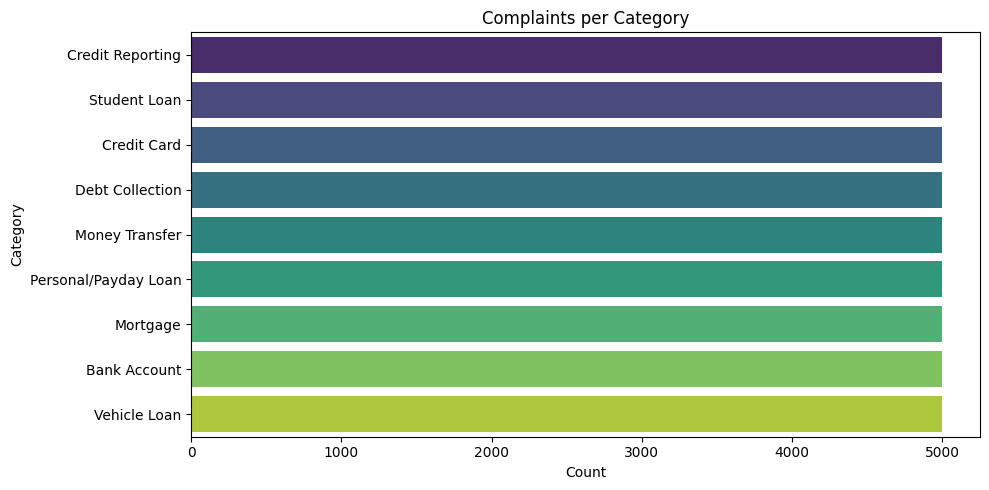

In [34]:
# Exploratory Data Analysis (EDA)
# 1. Check Category Distribution
print("\nCategory Counts:")
print(df['Product_Clean'].value_counts())

plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Product_Clean', palette='viridis')
plt.title("Complaints per Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

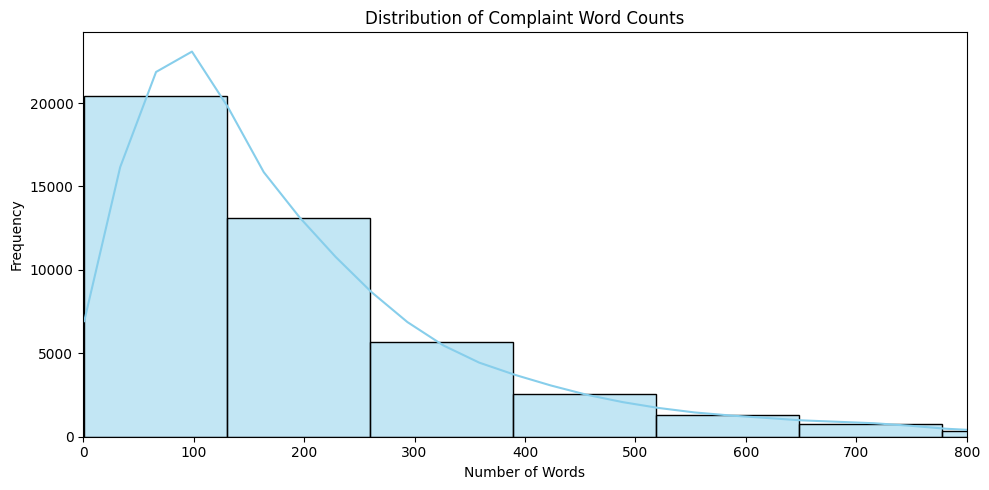

In [35]:
# 2. Analyze Text Lengths
df['word_count'] = df['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, color='skyblue', kde=True)
plt.title("Distribution of Complaint Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.xlim(0, 800)
plt.tight_layout()
plt.show()

In [36]:
df.head()

,Product_Clean,Consumer complaint narrative,word_count
0,Credit Reporting,I am submitting this complaint against XXXX an...,285
1,Credit Reporting,I am concerned about the validity and accuracy...,168
2,Credit Reporting,I am concerned about the validity and accuracy...,168
3,Credit Reporting,I received a call from a student loan company ...,93
4,Credit Reporting,These inquiries are unauthorized and fraudulen...,26


In [37]:
df.tail()

,Product_Clean,Consumer complaint narrative,word_count
44995,Vehicle Loan,I am not able to access my account or see the ...,311
44996,Vehicle Loan,CREDIT ACCEPTANCE provided a misleading contra...,93
44997,Vehicle Loan,XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX X...,325
44998,Vehicle Loan,We paid off our loan on XX/XX/XXXX. Our final ...,379
44999,Vehicle Loan,This loan is over 7 years old is was due to fa...,26


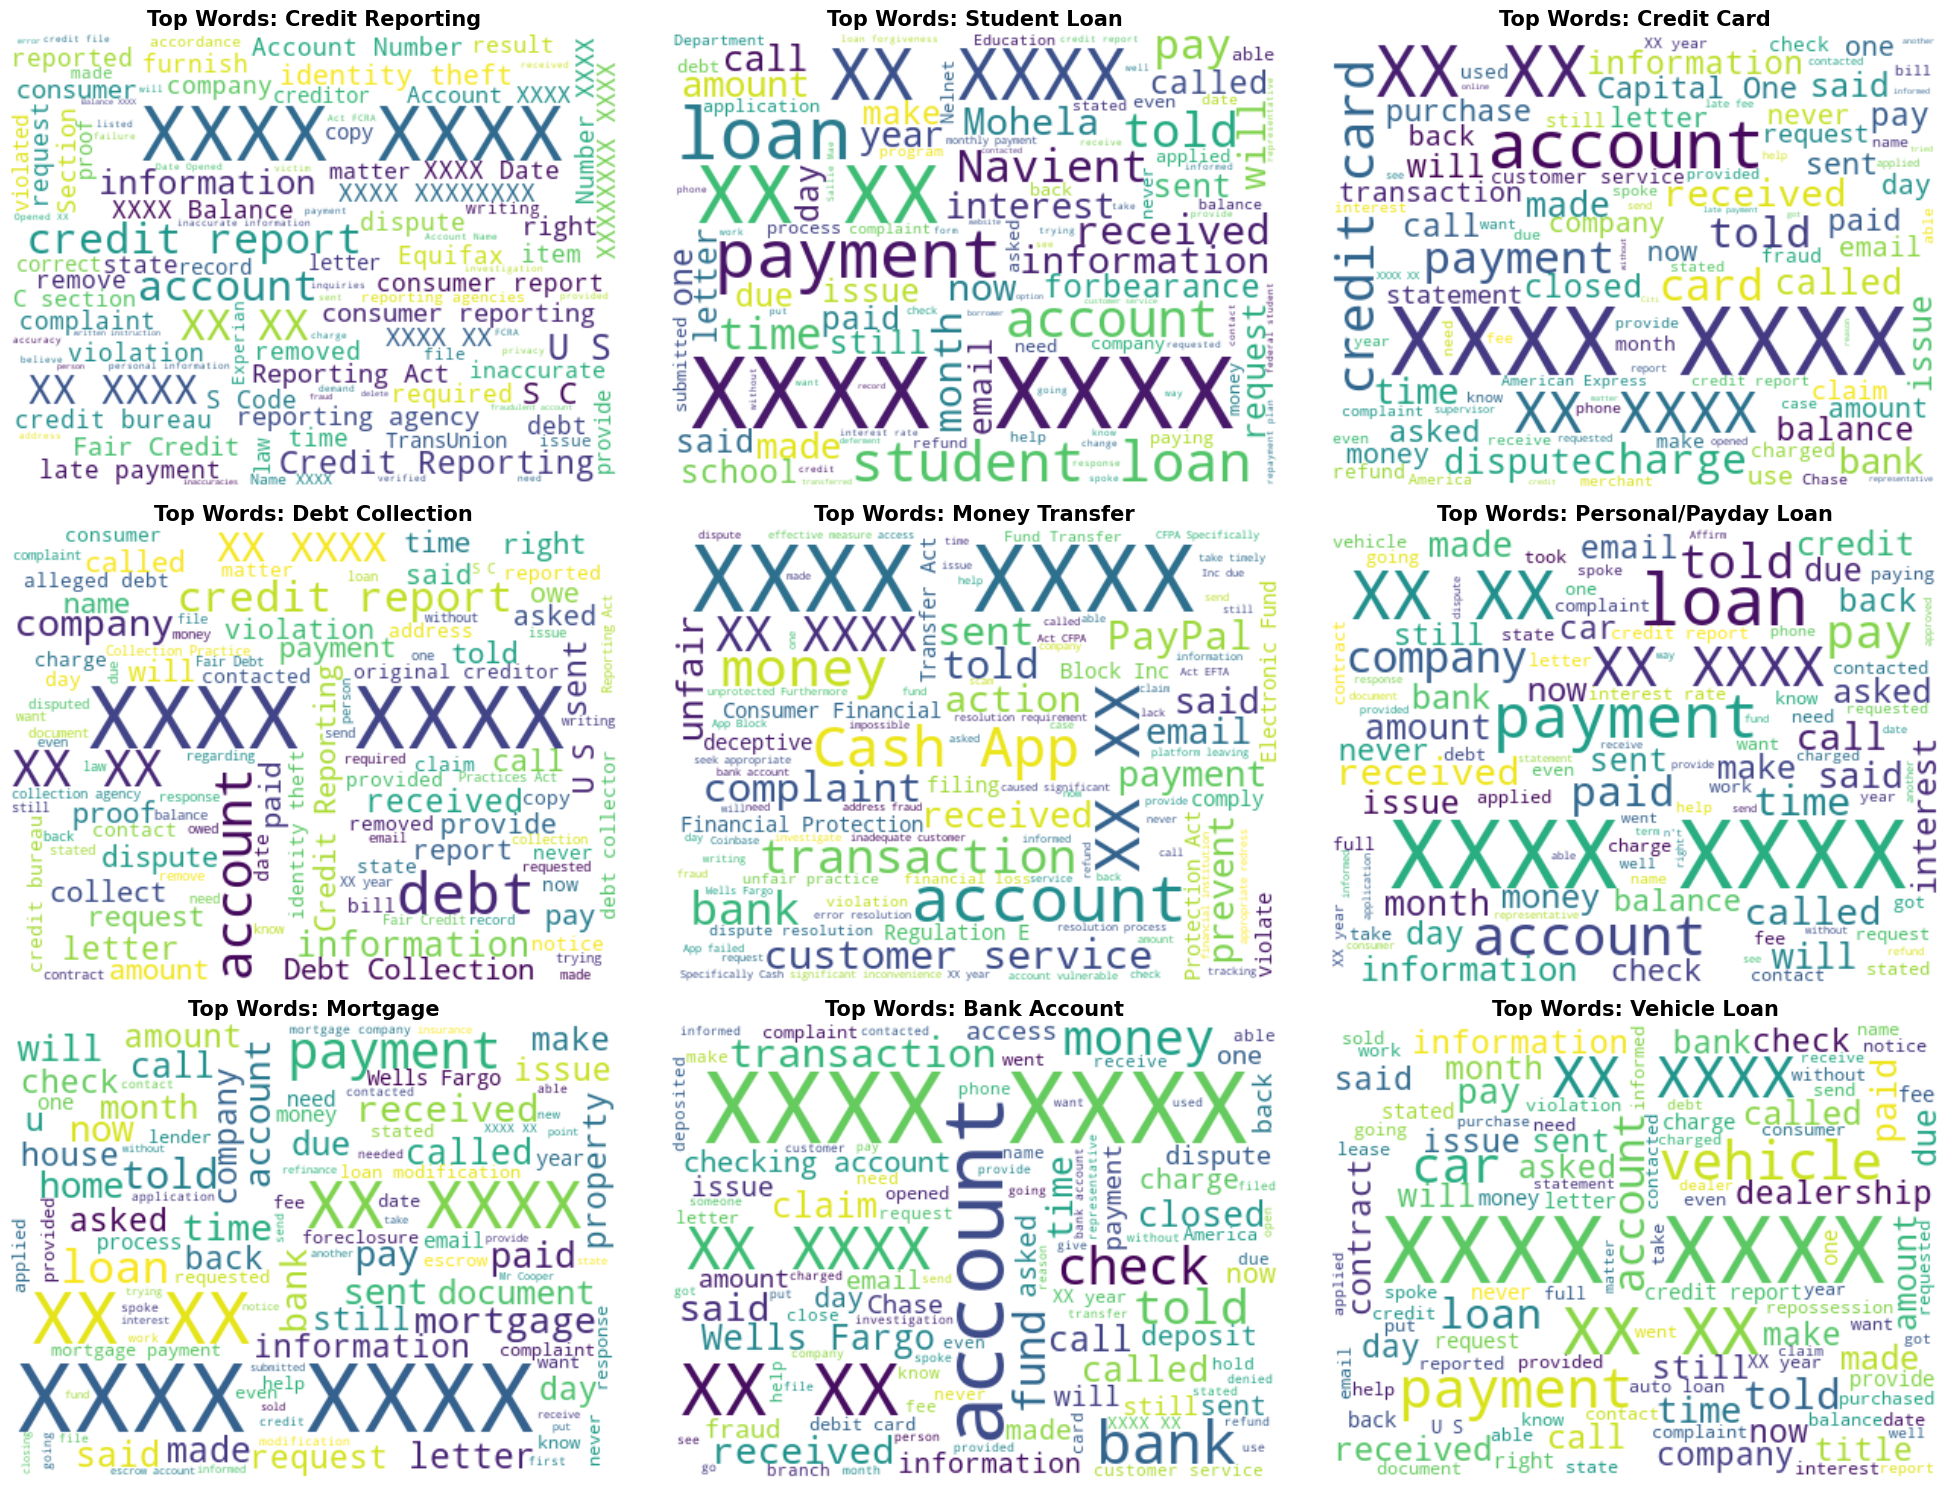

In [38]:
from wordcloud import WordCloud

def plot_word_clouds(df, category_col, text_col):
    categories = df[category_col].unique()
    
    plt.figure(figsize=(20, 15))
    
    for i, category in enumerate(categories):
        # Filter text for this specific category
        text_data = " ".join(df[df[category_col] == category][text_col].astype(str))
        
        # Generate Word Cloud
        wc = WordCloud(width=400, height=300, background_color='white', 
                       max_words=100, colormap='viridis').generate(text_data)
        
        plt.subplot(3, 3, i+1)
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Top Words: {category}", fontsize=15, fontweight='bold')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Run the visualization
plot_word_clouds(df, 'Product_Clean', 'Consumer complaint narrative')

In [ ]:
#XXXX is credntials that will be removed before building the model

In [39]:
# ------------------------------
# NLP PREPROCESSING (clean, consistent names)
# ------------------------------

import re
import string
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

nltk.download('stopwords')

# Column names
TEXT_COL = 'Consumer complaint narrative'
LABEL_COL = 'Product_Clean'

# 1. Separate features and target
texts = df[TEXT_COL].astype(str)
labels = df[LABEL_COL]

# 2. Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(labels)
NUM_CLASSES = len(label_encoder.classes_)
y_categorical = to_categorical(y_encoded, num_classes=NUM_CLASSES)

print(f'Number of classes: {NUM_CLASSES}')
print('Classes:', list(label_encoder.classes_))

# 3. Clean text (basic)
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    
    # 1. Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", ' ', text)
    
    # 2. Remove masked data (matches "xxxx", "xxxx-xxxx", "xx/xx/xxxx", etc.)
    text = re.sub(r'\bx+(?:[-/]*x+)*\b', ' ', text)
    
    # 3. Remove standalone numbers
    text = re.sub(r"\d+", ' ', text)
    
    # 4. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # 5. Remove stop words and words that are too short
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    
    return ' '.join(words)
# Apply the function to your text column
texts = texts.apply(clean_text)

# 4. TF-IDF (reference)
tfidf = TfidfVectorizer(use_idf=True, smooth_idf=True, sublinear_tf=True,
                        max_features=15000, stop_words='english', min_df=5, max_df=0.85)
X_tfidf = tfidf.fit_transform(texts)
print(f'TF-IDF matrix shape: {X_tfidf.shape}')

# 5. Tokenize and pad for deep models (consistent names)
MAX_WORDS = 10000
MAX_SEQUENCE_LENGTH = 200
print('Tokenizing text...')
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
X_sequences = tokenizer.texts_to_sequences(texts)
X_padded = pad_sequences(X_sequences, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

# 6. Train / test split (deep model inputs)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_padded, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded)

print(f'Training data shape: {X_train.shape}')
print(f'Testing data shape: {X_test.shape}')

NUM_CLASSES = 9


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Asus/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Number of classes: 9
Classes: ['Bank Account', 'Credit Card', 'Credit Reporting', 'Debt Collection', 'Money Transfer', 'Mortgage', 'Personal/Payday Loan', 'Student Loan', 'Vehicle Loan']
TF-IDF matrix shape: (45000, 12190)
Tokenizing text...
Training data shape: (36000, 200)
Testing data shape: (9000, 200)


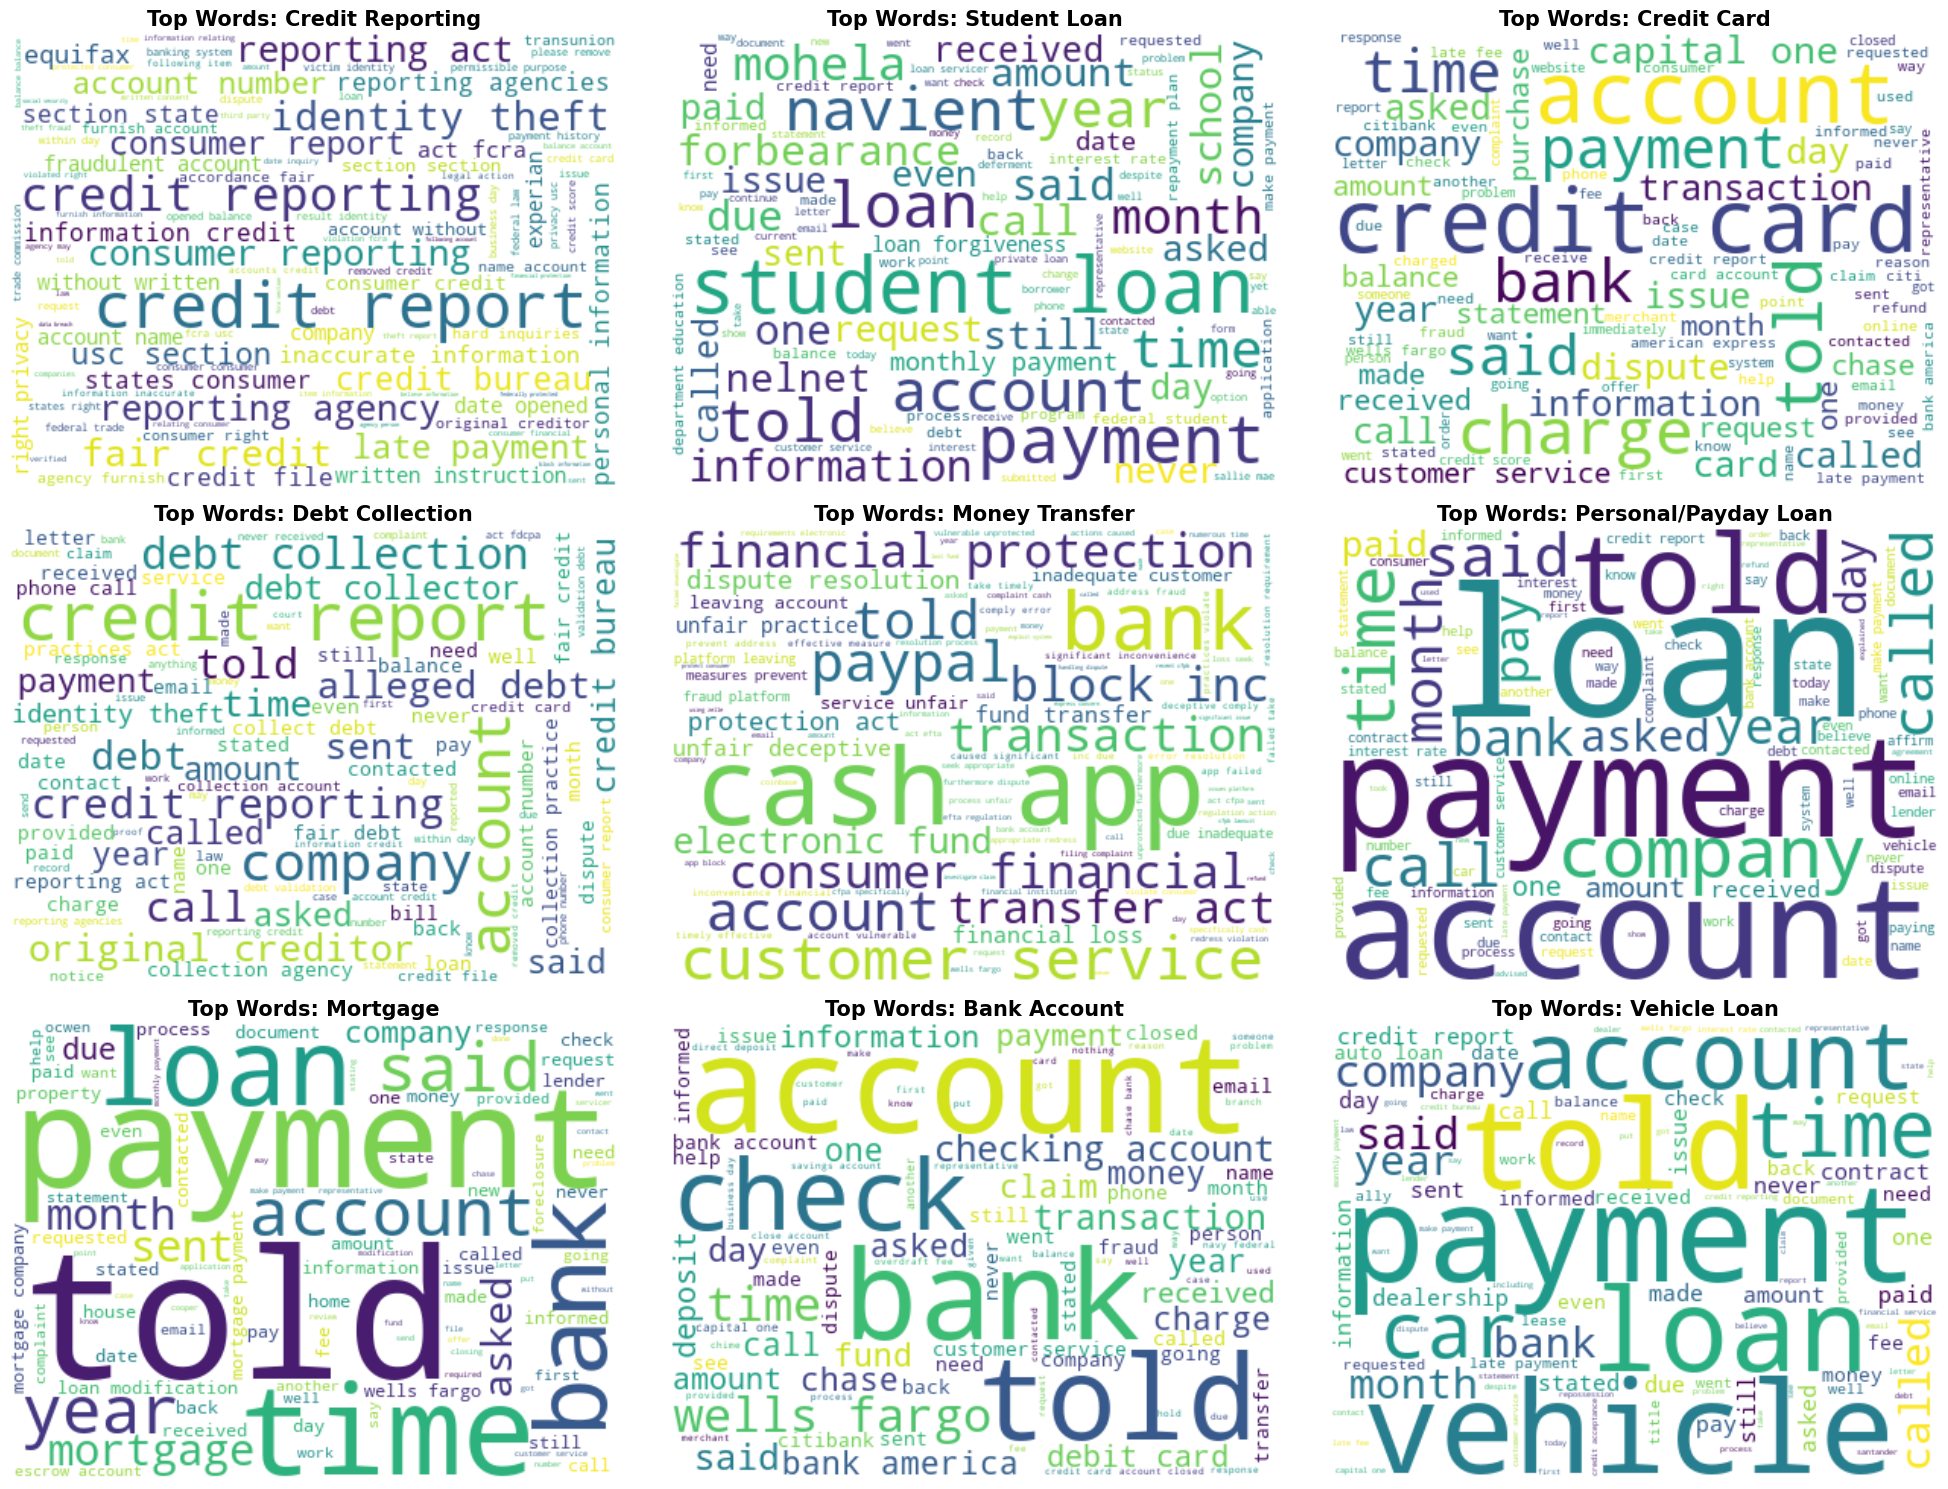

In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Add your cleaned 'texts' back into the DataFrame as a new column
df['cleaned_text'] = texts

# 2. Define the Word Cloud function
def plot_word_clouds(dataframe, category_col, text_col):
    categories = dataframe[category_col].unique()
    
    plt.figure(figsize=(20, 15))
    
    for i, category in enumerate(categories):
        # Filter the cleaned text for this specific category
        text_data = " ".join(dataframe[dataframe[category_col] == category][text_col].astype(str))
        
        # Generate Word Cloud
        wc = WordCloud(width=400, height=300, background_color='white', 
                       max_words=100, colormap='viridis').generate(text_data)
        
        plt.subplot(3, 3, i+1)
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Top Words: {category}", fontsize=15, fontweight='bold')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# 3. Run the visualization using the NEW 'cleaned_text' column
plot_word_clouds(df, 'Product_Clean', 'cleaned_text')


🚀 Starting Trial 1: SimpleRNN
Epoch 1/150
563/563 ━━━━━━━━━━━━━━━━━━━━ 63s 110ms/step - accuracy: 0.1767 - loss: 2.1383 - val_accuracy: 0.2568 - val_loss: 1.9806 - learning_rate: 1.0000e-04
Epoch 2/150
563/563 ━━━━━━━━━━━━━━━━━━━━ 59s 104ms/step - accuracy: 0.2964 - loss: 1.8538 - val_accuracy: 0.3561 - val_loss: 1.7171 - learning_rate: 1.0000e-04
Epoch 3/150
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.3537 - loss: 1.6819 - val_accuracy: 0.3952 - val_loss: 1.6317 - learning_rate: 1.0000e-04
Epoch 4/150
563/563 ━━━━━━━━━━━━━━━━━━━━ 58s 103ms/step - accuracy: 0.4014 - loss: 1.5690 - val_accuracy: 0.3784 - val_loss: 1.6545 - learning_rate: 1.0000e-04
Epoch 5/150
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 101ms/step - accuracy: 0.4328 - loss: 1.4865 - val_accuracy: 0.4231 - val_loss: 1.5988 - learning_rate: 1.0000e-04
Epoch 6/150
563/563 ━━━━━━━━━━━━━━━━━━━━ 57s 102ms/step - accuracy: 0.4634 - loss: 1.4228 - val_accuracy: 0.4454 - val_loss: 1.5610 - learning_rate: 1.0000e-04
Epoch 7/15

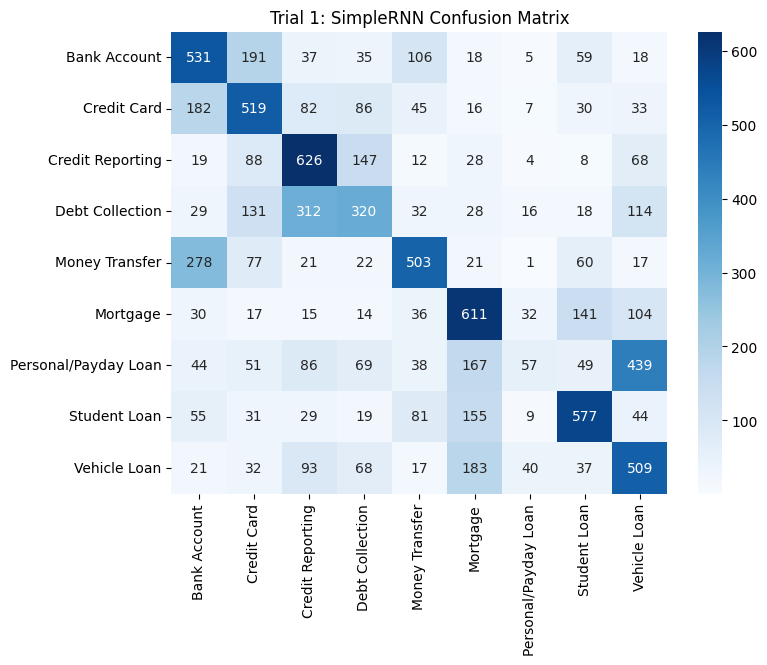

In [82]:
from tensorflow.keras.layers import SimpleRNN
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.optimizers.schedules import ExponentialDecay
import seaborn as sns
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
# --- Trial 1: SimpleRNN ---
print("🚀 Starting Trial 1: SimpleRNN")

model_rnn = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=150, input_length=MAX_SEQUENCE_LENGTH, ),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])


optimizer = Adam(learning_rate=0.0001)
model_rnn.compile(loss='categorical_crossentropy', optimizer= optimizer, metrics=['accuracy'])
early_stopping = EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True
)

lr_decay = ReduceLROnPlateau(
    monitor="val_loss", 
    factor=0.5, 
    patience=2, 
    verbose=1
)

model_rnn.fit(X_train, y_train, epochs=150, batch_size=64,callbacks=[early_stopping,lr_decay], validation_data=(X_test, y_test), verbose=1)

# Results & Evaluation
y_pred_rnn = np.argmax(model_rnn.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n--- Trial 1 Classification Report ---")
print(classification_report(y_true, y_pred_rnn, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred_rnn), annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Trial 1: SimpleRNN Confusion Matrix")
plt.show()

🚀 Starting Trial 2: LSTM
Epoch 1/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 297s 525ms/step - accuracy: 0.1324 - loss: 2.1673 - val_accuracy: 0.1194 - val_loss: 2.1955 - learning_rate: 0.0010
Epoch 2/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 300s 486ms/step - accuracy: 0.1185 - loss: 2.1919 - val_accuracy: 0.1278 - val_loss: 2.1943 - learning_rate: 0.0010
Epoch 3/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 282s 502ms/step - accuracy: 0.2007 - loss: 1.9423 - val_accuracy: 0.2332 - val_loss: 1.7215 - learning_rate: 0.0010
Epoch 4/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 288s 511ms/step - accuracy: 0.3619 - loss: 1.5040 - val_accuracy: 0.4544 - val_loss: 1.2296 - learning_rate: 0.0010
Epoch 5/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 287s 509ms/step - accuracy: 0.5168 - loss: 1.1437 - val_accuracy: 0.6510 - val_loss: 0.9812 - learning_rate: 0.0010
Epoch 6/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 278s 495ms/step - accuracy: 0.7166 - loss: 0.8515 - val_accuracy: 0.7469 - val_loss: 0.8000 - learning_rate: 0.0010
Epoch 7/50
563/563 ━━━━━━━━━━━━━━━━━━━━

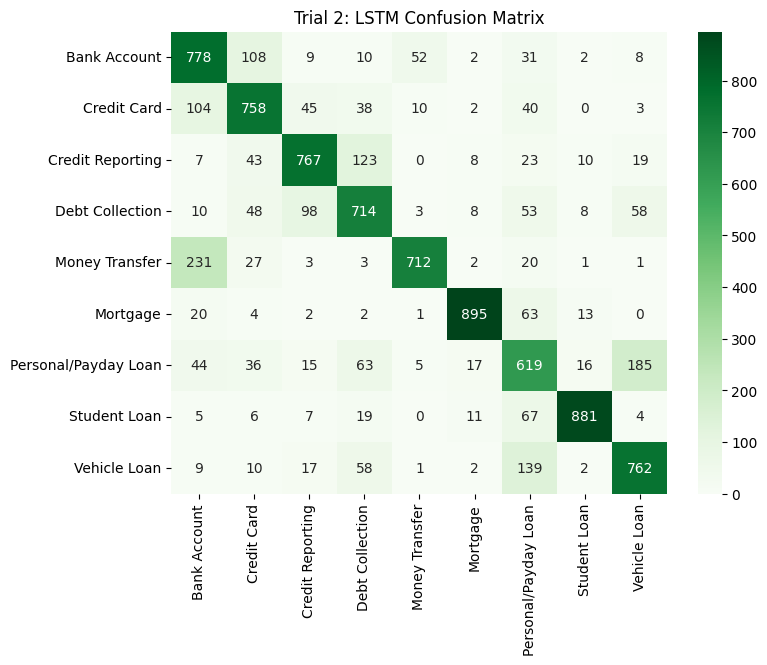

In [87]:
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense, SpatialDropout1D
# --- Trial 2: LSTM ---
print("🚀 Starting Trial 2: LSTM")

model_lstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=150, input_length=MAX_SEQUENCE_LENGTH),
    SpatialDropout1D(0.2),            # TUNING 1: Drops entire 1D feature maps to prevent relying on specific words
    LSTM(128),                        # TUNING 2: Increased from 64 to 128 for more memory capacity
    Dropout(0.5),
    Dense(64, activation='relu'),     # TUNING 3: Added an intermediate dense layer for better feature translation
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])


optimizer = Adam(learning_rate=0.001)
model_lstm.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
early_stopping = EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True
)
lr_decay = ReduceLROnPlateau(
    monitor="val_loss", 
    factor=0.5, 
    patience=2, 
    min_lr=1e-6,         # Prevents the learning rate from dropping to absolute zero
    verbose=1
)

model_lstm.fit(X_train, y_train, epochs=50, batch_size=64,callbacks=[early_stopping,lr_decay], validation_data=(X_test, y_test), verbose=1)

# Results & Evaluation
y_pred_lstm = np.argmax(model_lstm.predict(X_test), axis=1)

print("\n--- Trial 2 Classification Report ---")
print(classification_report(y_true, y_pred_lstm, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred_lstm), annot=True, fmt='d', cmap='Greens', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Trial 2: LSTM Confusion Matrix")
plt.show()


🚀 Starting Trial 3: Bidirectional LSTM
Epoch 1/25
563/563 ━━━━━━━━━━━━━━━━━━━━ 619s 1s/step - accuracy: 0.6344 - loss: 1.0895 - val_accuracy: 0.7759 - val_loss: 0.7221 - learning_rate: 0.0010
Epoch 2/25
563/563 ━━━━━━━━━━━━━━━━━━━━ 583s 1s/step - accuracy: 0.7904 - loss: 0.6906 - val_accuracy: 0.7897 - val_loss: 0.6783 - learning_rate: 0.0010
Epoch 3/25
563/563 ━━━━━━━━━━━━━━━━━━━━ 602s 1s/step - accuracy: 0.8250 - loss: 0.5897 - val_accuracy: 0.7877 - val_loss: 0.7085 - learning_rate: 0.0010
Epoch 4/25
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.8514 - loss: 0.5112
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
563/563 ━━━━━━━━━━━━━━━━━━━━ 586s 1s/step - accuracy: 0.8454 - loss: 0.5244 - val_accuracy: 0.7884 - val_loss: 0.7139 - learning_rate: 0.0010
Epoch 5/25
563/563 ━━━━━━━━━━━━━━━━━━━━ 592s 1s/step - accuracy: 0.8736 - loss: 0.4330 - val_accuracy: 0.7814 - val_loss: 0.7629 - learning_rate: 5.0000e-04
Epoch 6/25
563/563 ━━━━━━━━━━━━━━━━━━━━

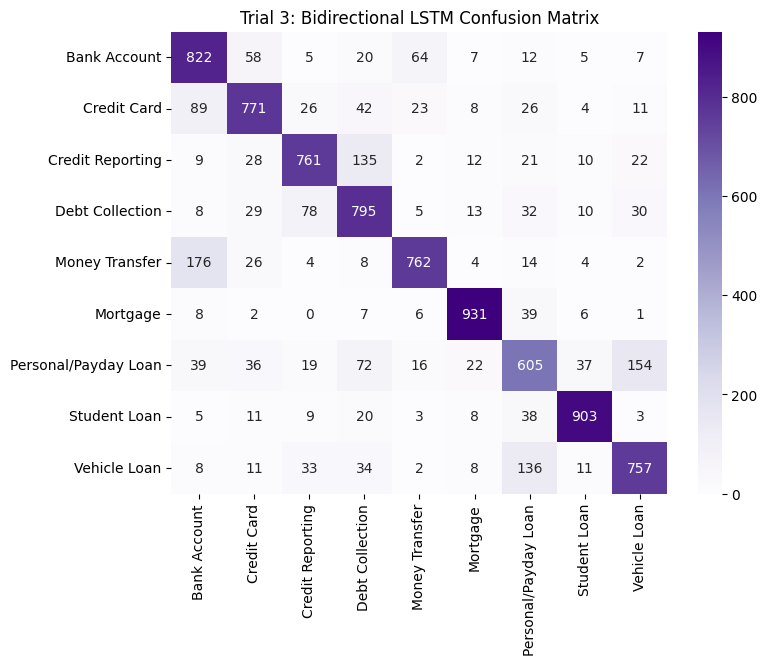

In [88]:
from tensorflow.keras.layers import Bidirectional

# --- Trial 3: Bidirectional LSTM ---
print("🚀 Starting Trial 3: Bidirectional LSTM")

model_bilstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=150, input_length=MAX_SEQUENCE_LENGTH),
    SpatialDropout1D(0.2),  # Prevents overfitting on specific vocabulary words
    
    # BiLSTM with 128 units (effectively 256 units because it runs both ways)
    Bidirectional(LSTM(128)),
    
    Dropout(0.5),
    Dense(64, activation='relu'), # Helps translate the massive BiLSTM output into categories
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])
optimizer = Adam(learning_rate=0.001)
model_bilstm.compile(loss='categorical_crossentropy', optimizer= optimizer, metrics=['accuracy'])
early_stopping = EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True
)
lr_decay = ReduceLROnPlateau(
    monitor="val_loss", 
    factor=0.5, 
    patience=2, 
    min_lr=1e-6,
    verbose=1
)


model_bilstm.fit(X_train, y_train, epochs=25, batch_size=64,callbacks=[early_stopping,lr_decay], validation_data=(X_test, y_test), verbose=1)

# Results & Evaluation
y_pred_bilstm = np.argmax(model_bilstm.predict(X_test), axis=1)

print("\n--- Trial 3 Classification Report ---")
print(classification_report(y_true, y_pred_bilstm, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred_bilstm), annot=True, fmt='d', cmap='Purples', 
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Trial 3: Bidirectional LSTM Confusion Matrix")
plt.show()

🚀 Training Trial 4: CNN-BiLSTM Hybrid...
Epoch 1/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 182s 319ms/step - accuracy: 0.6392 - loss: 1.0467 - val_accuracy: 0.7923 - val_loss: 0.6795 - learning_rate: 0.0010
Epoch 2/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 180s 319ms/step - accuracy: 0.8037 - loss: 0.6468 - val_accuracy: 0.7972 - val_loss: 0.6496 - learning_rate: 0.0010
Epoch 3/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 178s 317ms/step - accuracy: 0.8387 - loss: 0.5369 - val_accuracy: 0.8064 - val_loss: 0.6393 - learning_rate: 0.0010
Epoch 4/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 177s 315ms/step - accuracy: 0.8621 - loss: 0.4568 - val_accuracy: 0.8003 - val_loss: 0.6537 - learning_rate: 0.0010
Epoch 5/50
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - accuracy: 0.8913 - loss: 0.3687
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
563/563 ━━━━━━━━━━━━━━━━━━━━ 176s 313ms/step - accuracy: 0.8859 - loss: 0.3847 - val_accuracy: 0.7937 - val_loss: 0.7476 - learning_rate: 0.0010
Epoch 6/50
563/563 ━━━━━━━

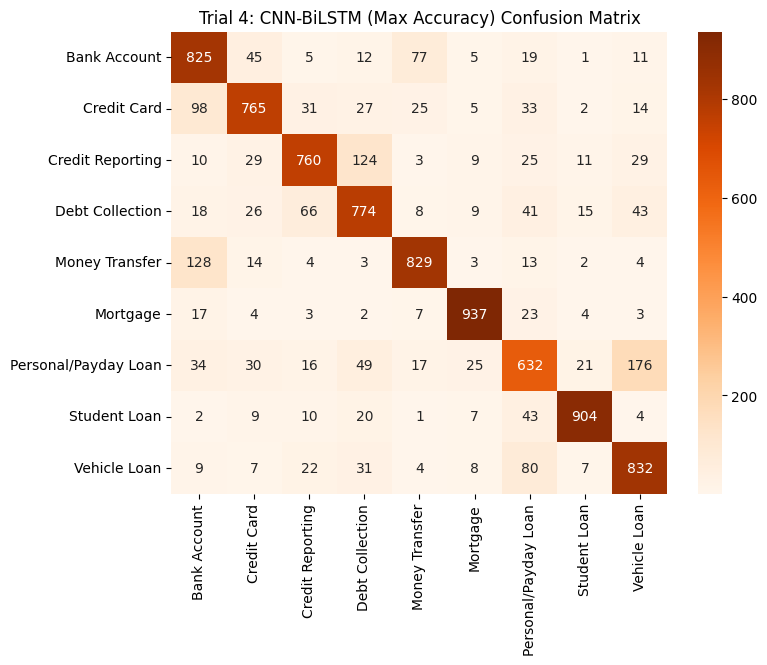

In [89]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Bidirectional, Dropout, Dense, SpatialDropout1D, GlobalMaxPooling1D
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# --- Trial 4: CNN-BiLSTM Hybrid (Maximum Accuracy Tune) ---
print("🚀 Training Trial 4: CNN-BiLSTM Hybrid...")

model_hybrid = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=150, input_length=MAX_SEQUENCE_LENGTH),
    SpatialDropout1D(0.2),  
    
    # CNN extracts local patterns
    Conv1D(filters=128, kernel_size=5, activation='relu'),  
    MaxPooling1D(pool_size=4),
    
    # 🌟 PRO TRICK: return_sequences=True forces the LSTM to output its thoughts for EVERY word
    Bidirectional(LSTM(128, return_sequences=True)),  
    
    # 🌟 PRO TRICK: Pulls the absolute strongest features from across the entire sequence
    GlobalMaxPooling1D(),
    
    Dense(64, activation='relu'),
    Dropout(0.4), # Slightly lowered from 0.5 so it doesn't lose too much information
    Dense(NUM_CLASSES, activation='softmax')
])

# Start at 0.001 (Faster) so it doesn't get stuck in a bad local minimum early on
optimizer = Adam(learning_rate=0.001)
model_hybrid.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

# Increased patience to 5 because our learning rate is starting faster
early_stopping = EarlyStopping(
    monitor="val_loss", 
    patience=5, 
    restore_best_weights=True
)

lr_decay = ReduceLROnPlateau(
    monitor="val_loss", 
    factor=0.5, 
    patience=2, 
    min_lr=1e-6,
    verbose=1
)

# Set epochs to 50, Early Stopping will handle the rest
model_hybrid.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=64,
    callbacks=[early_stopping, lr_decay], 
    validation_data=(X_test, y_test), 
    verbose=1
)

# Evaluate
y_pred_hybrid = np.argmax(model_hybrid.predict(X_test), axis=1)

print("\n--- Trial 4: Hybrid Classification Report ---")
print(classification_report(y_true, y_pred_hybrid, target_names=label_encoder.classes_))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_true, y_pred_hybrid), annot=True, fmt='d', cmap='Oranges',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Trial 4: CNN-BiLSTM (Max Accuracy) Confusion Matrix")
plt.show()


In [90]:
import numpy as np
from sklearn.metrics import accuracy_score

# y_true is the ground truth (actual categories)
y_true = np.argmax(y_test, axis=1)

Trial 1 (SimpleRNN):        0.4726
Trial 2 (LSTM):             0.7651
Trial 3 (Bi-LSTM):          0.7897
Trial 4 (Hybrid CNN-LSTM):  0.8043


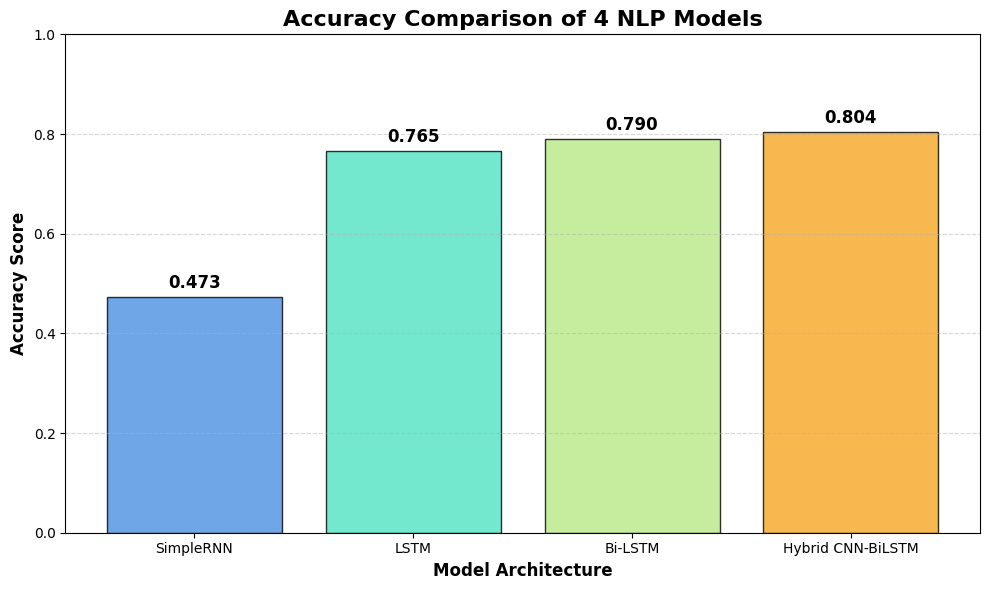

In [98]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

acc_rnn = accuracy_score(y_true, y_pred_rnn)
acc_lstm = accuracy_score(y_true, y_pred_lstm)
acc_bilstm = accuracy_score(y_true, y_pred_bilstm)
acc_hybrid = accuracy_score(y_true, y_pred_hybrid)  


print(f"Trial 1 (SimpleRNN):        {acc_rnn:.4f}")
print(f"Trial 2 (LSTM):             {acc_lstm:.4f}")
print(f"Trial 3 (Bi-LSTM):          {acc_bilstm:.4f}")
print(f"Trial 4 (Hybrid CNN-LSTM):  {acc_hybrid:.4f}")

models = ['SimpleRNN', 'LSTM', 'Bi-LSTM', 'Hybrid CNN-BiLSTM']
accuracies = [acc_rnn, acc_lstm, acc_bilstm, acc_hybrid]

# Using a clean, professional color palette
colors = ['#4A90E2', '#50E3C2', '#B8E986', '#F5A623'] 

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

# Formatting the chart
plt.ylim(0, 1.0) # Accuracy scale from 0 to 1
plt.title("Accuracy Comparison of 4 NLP Models", fontsize=16, fontweight='bold')
plt.ylabel("Accuracy Score", fontsize=12, fontweight='bold')
plt.xlabel("Model Architecture", fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Display the final chart
plt.tight_layout()
plt.show()

In [92]:
import pickle

# ==========================================
# 1. SAVE ALL 4 DEEP LEARNING MODELS (.h5)
# ==========================================
print("💾 Saving Deep Learning Models...")

# Trial 1: SimpleRNN
model_rnn.save('model_1_simple_rnn(new).h5')
print("✔️ SimpleRNN saved as 'model_1_simple_rnn.h5'")

# Trial 2: LSTM
model_lstm.save('model_2_lstm(new).h5')
print("✔️ LSTM saved as 'model_2_lstm.h5'")

# Trial 3: Bi-LSTM
model_bilstm.save('model_3_bilstm(new).h5')
print("✔️ Bi-LSTM saved as 'model_3_bilstm.h5'")

# Trial 4: CNN-LSTM Hybrid
model_hybrid.save('model_4_hybrid_cnn_lstm(new).h5')
print("✔️ Hybrid CNN-LSTM saved as 'model_4_hybrid_cnn_lstm.h5'")


# ==========================================
# 2. SAVE THE PREPROCESSORS (.pkl)
# ==========================================
print("\n💾 Saving Preprocessors (Needed to translate text to numbers)...")

# Save the Tokenizer
with open('tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✔️ Tokenizer saved as 'tokenizer.pkl'")

# Save the Label Encoder
with open('label_encoder.pkl', 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✔️ Label Encoder saved as 'label_encoder.pkl'")

print("\n🎉 ALL DONE! Your entire project is safely backed up to your hard drive.")

💾 Saving Deep Learning Models...
✔️ SimpleRNN saved as 'model_1_simple_rnn.h5'


✔️ LSTM saved as 'model_2_lstm.h5'
✔️ Bi-LSTM saved as 'model_3_bilstm.h5'
✔️ Hybrid CNN-LSTM saved as 'model_4_hybrid_cnn_lstm.h5'

💾 Saving Preprocessors (Needed to translate text to numbers)...
✔️ Tokenizer saved as 'tokenizer.pkl'
✔️ Label Encoder saved as 'label_encoder.pkl'

🎉 ALL DONE! Your entire project is safely backed up to your hard drive.
